In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from decimal import Decimal
import matplotlib.pyplot as plt


In [5]:
INPUT_CSV   = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/cornet_bbox/vit_tiny/individuation/geogaze_results/geogaze_model_predictions_individuation_bbox.csv")    #individuation csv 
MODELS_ROOT = Path("/zpool/vladlab/data_drive/geogaze_data/geogaze_final/vit_tiny_geogaze_task/individuation_geogaze_task")  # contains folders named by values in `model`
MASKS_ROOT  = Path("/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/test_stimuli/test_acc_masks")      # contains target/distractor mask images
OUTPUT_CSV  = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/cornet_bbox/vit_tiny/individuation/geogaze_results/geogaze_model_predictions_individuation_bbox_pred_avg1.csv")

# Column names in your master CSV
COL_MODEL      = "model"
COL_TEST_IMAGE = "test_image"
COL_TARGET     = "target"
COL_DISTRACTOR = "distractor"

DECIMAL_PLACES = 10


In [6]:
#take mask with white background black object and turn it into a binary array where white pixels are 0, black pixels are 1

def load_mask_df(img_path: str | Path) -> pd.DataFrame:
    """
    Load black/white mask image -> binary mask DataFrame (224x224):
      black object -> 1
      white background -> 0
    """
    img_path = Path(img_path)
    img = Image.open(img_path).convert("L")
    arr = np.array(img, dtype=np.uint8)

    # white -> 1, black -> 0
    bw = (arr > 127).astype(np.uint8)

    # invert so black object -> 1
    mask = 1 - bw
    return pd.DataFrame(mask)

def load_prob_map_df(csv_path: str | Path) -> pd.DataFrame:
    """
    Load probability map CSV as a DataFrame (224x224).
    Assumes it's clean and already exactly the matrix (no index col).
    """
    csv_path = Path(csv_path)
    return pd.read_csv(csv_path, header=None)

def masked_mean_df(x_df: pd.DataFrame, mask_df: pd.DataFrame) -> float:
    """
    Mean of x where mask == 1, using DataFrames.
    """
    # This creates a DataFrame with values where mask==1 and NaN elsewhere
    masked = x_df.where(mask_df == 1)
    return float(masked.stack().mean())  # stack() drops NaNs

def prob_csv_name_from_test_image(test_image: str) -> str:
    stem = Path(test_image).stem
    return f"{stem}_prob_map.csv"


In [7]:
df = pd.read_csv(INPUT_CSV)

target_means = []
distractor_means = []

for _, row in df.iterrows():
    model_folder = MODELS_ROOT / row["model"]

    prob_csv = prob_csv_name_from_test_image(row["test_image"])
    prob_map_path = model_folder / prob_csv

    target_mask_path = MASKS_ROOT / row["target"]
    distractor_mask_path = MASKS_ROOT / row["distractor"]

    x_df = load_prob_map_df(prob_map_path)
    target_mask_df = load_mask_df(target_mask_path)
    distractor_mask_df = load_mask_df(distractor_mask_path)

    target_means.append(masked_mean_df(x_df, target_mask_df))
    distractor_means.append(masked_mean_df(x_df, distractor_mask_df))

df["target_mean"] = target_means
df["distractor_mean"] = distractor_means

# Save with no scientific notation
df.to_csv(OUTPUT_CSV, index=False, float_format=f"%.{DECIMAL_PLACES}f")

OUTPUT_CSV

PosixPath('/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/cornet_bbox/vit_tiny/individuation/geogaze_results/geogaze_model_predictions_individuation_bbox_pred_avg1.csv')

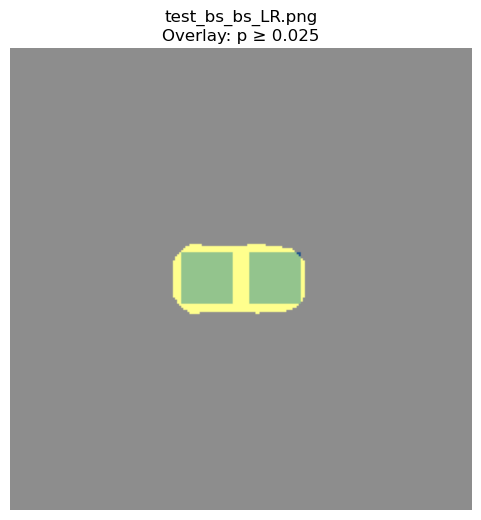

In [8]:
IMAGE_ROOT  = Path("/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/test_stimuli/test_pairs/")

ROW_IDX = 2
THRESH = 0.025  # <-- probability threshold



# Load row info
row = df.iloc[ROW_IDX]

# Original image
img_path = IMAGE_ROOT / row["test_image"]
img = Image.open(img_path).convert("RGB")
img_arr = np.array(img)

# Prediction map
model_folder = MODELS_ROOT / row["model"]
prob_csv = f"{Path(row['test_image']).stem}_prob_map.csv"
prob_map_path = model_folder / prob_csv

prob_df = pd.read_csv(prob_map_path, header=0)
prob_arr = prob_df.to_numpy()

# Threshold the prediction map
high_prob = prob_arr >= THRESH


# Build overlay 
overlay = np.zeros_like(img_arr)
overlay[..., 0] = high_prob * 255   
overlay[..., 1] = high_prob * 255   
overlay[..., 2] = 0                 


# Plot
plt.figure(figsize=(6, 6))
plt.imshow(img_arr)
plt.imshow(overlay, alpha=0.45)
plt.axis("off")
plt.title(
    f"{row['test_image']}\n"
    f"Overlay: p ≥ {THRESH}"
)
plt.show()

In [2]:
import pandas as pd
import numpy as np

# 1. Load the existing CSV
df = pd.read_csv("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/cornet_bbox/resnet18_bboxes/identification/geogaze_results/geogaze_model_predictions_identification_bbox_pred_avg_ratio.csv")

# 2. Create the new column
denom = df["target_mean"] + df["distractor_mean"]
df["ratio"] = df["target_mean"] / denom.replace(0, np.nan)

# 3. Write it back out (overwrite or new file)

df.to_csv("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/cornet_bbox/resnet18_bboxes/identification/geogaze_results/geogaze_model_predictions_identification_bbox_pred_avg_ratio.csv", index=False)  # safer: new file
